**Introduction to Artificial Intelligence Lab 1A**<br>
Part 1: running imports

In [21]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from itertools import count
from typing import Any, Dict, Iterable, List, Optional, Tuple
import heapq

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
#print("I want to be cracked at intro to ai")

Part 2: Abstract Problem Interface

In [22]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

Part 3: The Node Class definition

In [23]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1

Part 3b: The SearchResult Class

In [24]:
@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

Part 4: Helper Functions

In [25]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

Part 5: My GridProblem Implementation

In [26]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}

class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        if state == self.goal:
          return True
        else:
          return False

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        row,col =state
        legal_actions=[]
        if self.in_bounds((row-1,col)) and self.is_free((row-1,col)):
          legal_actions.append("UP")
        if self.in_bounds((row+1,col)) and self.is_free((row+1,col)):
          legal_actions.append("DOWN")
        if self.in_bounds((row,col-1)) and self.is_free((row,col-1)):
          legal_actions.append("LEFT")
        if self.in_bounds((row,col+1)) and self.is_free((row,col+1)):
          legal_actions.append("RIGHT")
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        dr,dc=MOVES[action]
        return (row+dr,col+dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1.0

Part 5.1: GridProblem test

In [27]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


Part 6: Suggested Sample Drone Map

In [28]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

Part 7: Helpful Visualization Functions

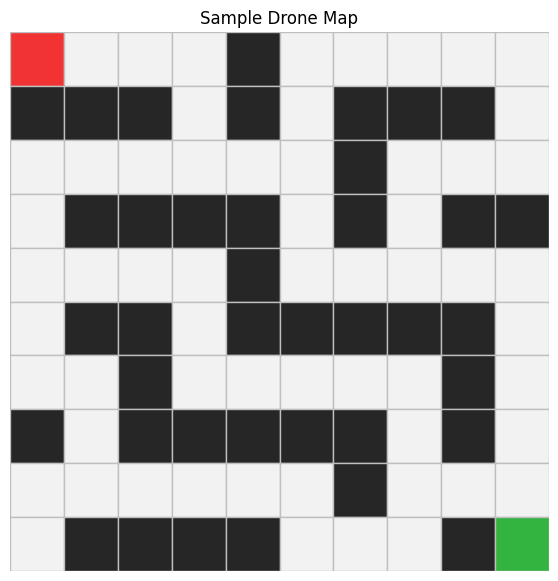

In [29]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()
plot_path(sample_grid, start, goal, title="Sample Drone Map")

Part 8: The Shared Expand Method

In [30]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        state=node.state
        for action in problem.actions(state):
            s_prime=problem.result(state,action)
            cost=node.path_cost+problem.action_cost(state,action,s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

Part 9: Breadth-First Search

In [31]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        nodes_expanded=0
        max_frontier_size=0
        node=Node(state=problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=len(reached)
            )
        frontier=deque([node])
        reached={problem.initial_state()}
        max_frontier_size=len(frontier)

        while len(frontier) > 0:
            node=frontier.popleft()
            nodes_expanded+=1
            for child in self.expand(problem, node):
                s=child.state
                if problem.is_goal(s):
                  return SearchResult(
                      algorithm=algorithm,
                      status="success",
                      solution=child,
                      nodes_expanded=nodes_expanded,
                      max_frontier_size=max_frontier_size,
                      reached_count=len(reached)
                  )
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            if len(frontier)>max_frontier_size:
                max_frontier_size=len(frontier)
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

Part 10: Depth-First Search

In [32]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        nodes_expanded=0
        max_frontier_size=0
        node=Node(state=problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=len(reached)
            )
        frontier=[node]
        reached={problem.initial_state()}
        max_frontier_size=len(frontier)

        while len(frontier) > 0:
            node=frontier.pop()
            nodes_expanded+=1

            for child in self.expand(problem, node):
                s=child.state
                if problem.is_goal(s):
                    return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=child,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached)
                )
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            if len(frontier)>max_frontier_size:
                max_frontier_size=len(frontier)
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

Part 11: Depth Limited Search

In [33]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return (node,"success")
        elif node.depth>=limit:
            return (None,"cutoff")
        else:
            metrics["nodes_expanded"]+=1
            cuttoff_occured=False
            for child in self.expand(problem, node):
                s=child.state
                if state_is_on_path(node,s):
                    continue
                metrics["max_stack_size"]+=1
                result,status=self._recursive_dls(
                                  problem=problem,
                                  node=child,
                                  limit=limit,
                                  metrics=metrics,
                                  current_stack_size=current_stack_size+1,
                              )
                if status=="success":
                    return (result,status)
                elif status=="cutoff":
                    cuttoff_occured=True
            if cuttoff_occured:
                return (None,"cutoff")
            else:
                return (None,"failure")

Part 12: Iterative Deepening Search

In [34]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"
        dls=DepthLimitedSearch()
        iteration_log=[]
        total_nodesexpanded=0
        max_frontier_size=0
        for i in range(max_depth+1):
          result=dls.search(problem=problem,limit=i)
          total_nodesexpanded+=result.nodes_expanded
          if result.max_frontier_size>max_frontier_size:
            max_frontier_size=result.max_frontier_size
          iteration_log.append(result.status)#record in iteration log
          result.algorithm=algorithm
          result.limit=i
          result.max_frontier_size=max_frontier_size
          result.nodes_expanded=total_nodesexpanded
          result.reached_count=len(iteration_log)
          if result.status=="success":
            return result
          elif result.status=="failure":
            return SearchResult(
                algorithm=algorithm,
                status="failure",
                solution=None,
                nodes_expanded=total_nodesexpanded,
                max_frontier_size=max_frontier_size,
                reached_count=len(iteration_log)
            )
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodesexpanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(iteration_log)
        )

Part 13: Run the Algorithms on the Sample Map

In [35]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,18.0,18.0,18,4,21
2,DLS,cutoff,10.0,NaN,NaN,16,19,0
3,IDS,success,18.0,18.0,18.0,356,60,19


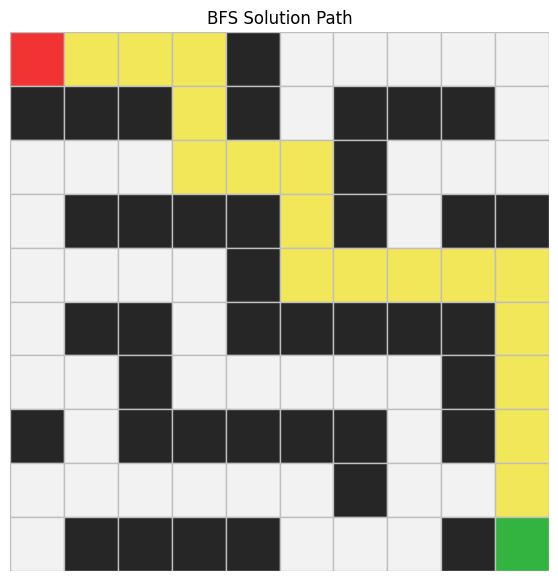

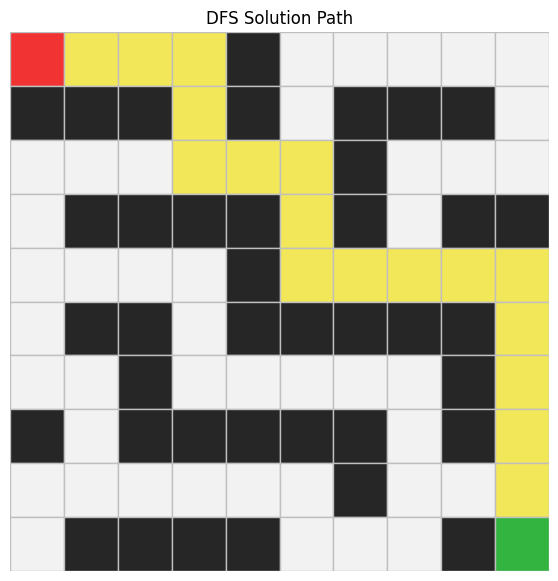

In [36]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

Part 14: Create your own maps

In [37]:
# Create your first custom map here.
custom_grid_1 = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0,0,1],
    [1, 1, 0, 0, 1, 0, 1, 1, 1, 0,1,0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0,0,0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1,0,0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0,0,0],
    [0, 1, 1, 0, 1, 1, 0, 1, 1, 0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0,1,0],
    [1, 0, 1, 0, 0, 1, 1, 0, 1, 0,1,0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0,0,0],
    [0, 1, 1, 0, 1, 0, 0, 0, 1, 0,0,0],
    [0, 0, 0, 1, 0, 0, 1, 0, 0, 0,1,0],
    [0, 0, 0, 0, 1, 0, 1, 0, 1, 0,0,0],
]
custom_start_1 = (0,0)
custom_goal_1 = (11,11)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
     bfs.search(custom_problem_1),
     dfs.search(custom_problem_1),
     dls.search(custom_problem_1, limit=20),
     ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,22.0,22.0,99,10,100
1,DFS,success,NaN,30.0,30.0,70,22,85
2,DLS,cutoff,20.0,NaN,NaN,1230,1860,0
3,IDS,success,22.0,22.0,22.0,6338,2632,23


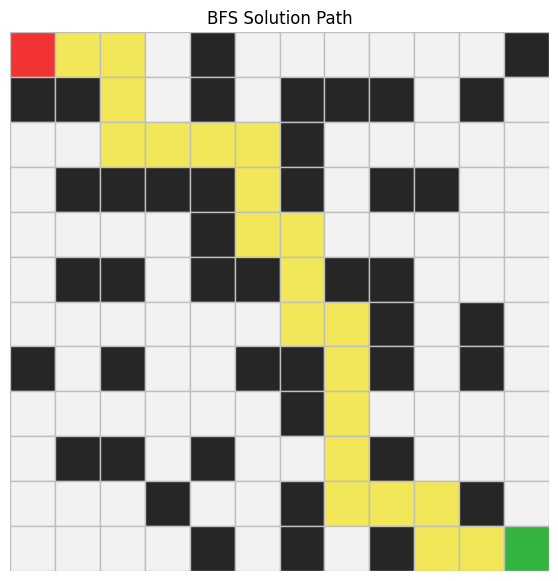

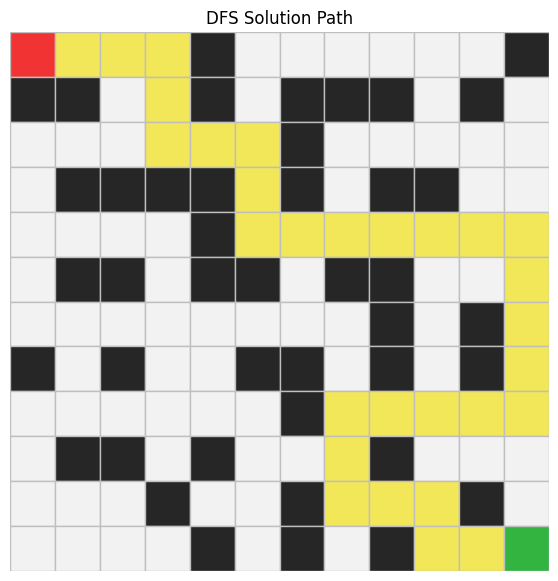

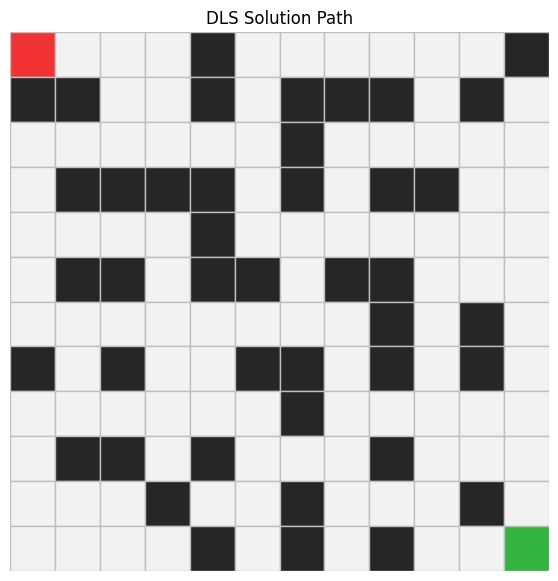

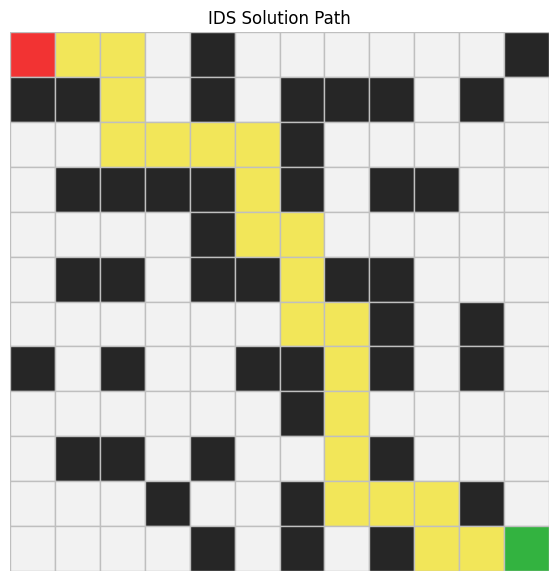

In [38]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="BFS Solution Path",
)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    title="DFS Solution Path",
)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[2].path,
    title="DLS Solution Path",
)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[3].path,
    title="IDS Solution Path",
)

In [39]:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0,0,1,0,0,0],
    [1, 1, 0, 0, 1, 0, 1, 1, 1, 0,1,0,0,0,0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0,0,0,1,0,0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1,0,0,1,1,1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0,0,0,0,0,1],
    [0, 1, 1, 0, 1, 1, 0, 1, 1, 0,0,0,0,0,0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0,1,0,1,0,1],
    [1, 0, 1, 0, 0, 1, 1, 0, 1, 0,1,0,0,1,1],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0,0,0,0,0,0],
    [0, 1, 1, 0, 1, 0, 0, 0, 1, 0,0,0,0,1,0],
    [0, 0, 0, 1, 0, 0, 1, 0, 0, 0,1,0,0,0,1],
    [0, 0, 0, 0, 1, 0, 1, 0, 1, 0,0,0,0,0,0],
    [0, 0, 1, 0, 1, 0, 0, 0, 1, 1,0,0,0,1,0],
    [0, 0, 1, 1, 0, 1, 1, 0, 0, 0,0,0,0,0,1],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 0,0,0,0,0,0],
]

custom_start_2 = (0,1)
custom_goal_2 = (13,13)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,25.0,25.0,153,15,155
1,DFS,success,NaN,35.0,35.0,97,25,122
2,DLS,cutoff,20.0,NaN,NaN,2238,3537,0
3,IDS,success,25.0,25.0,25.0,39699,21029,26


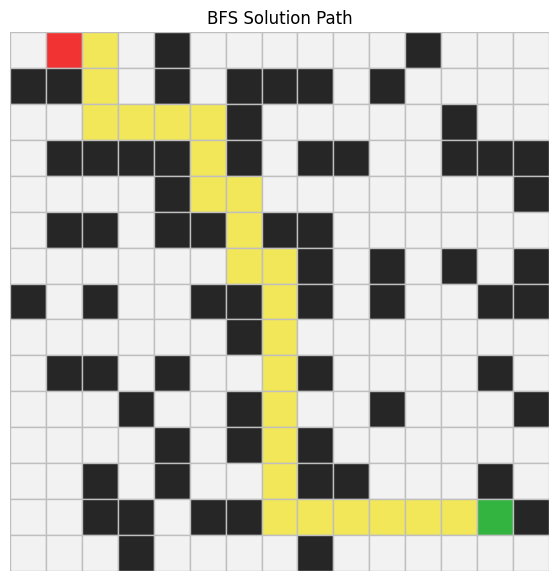

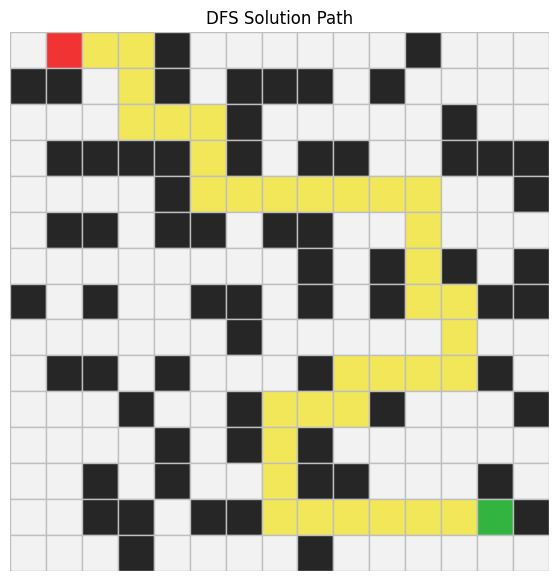

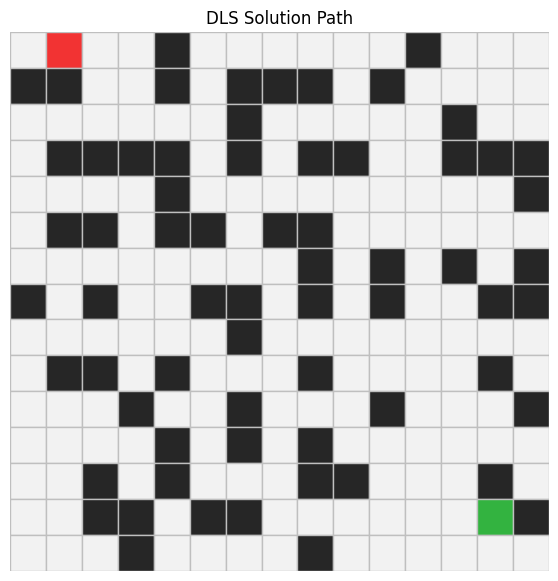

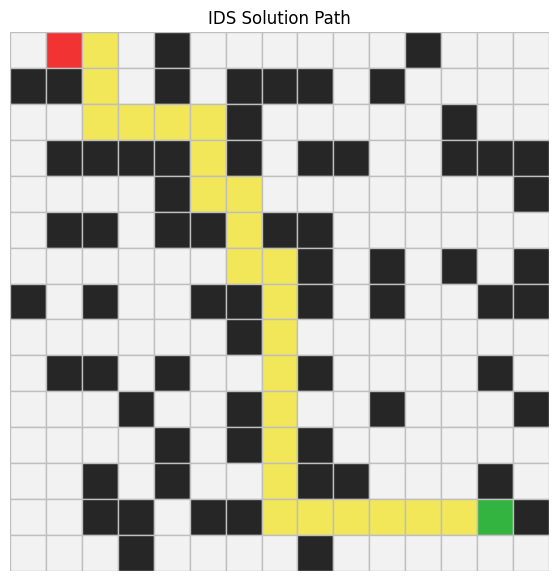

In [40]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    title="BFS Solution Path",
)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    title="DFS Solution Path",
)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[2].path,
    title="DLS Solution Path",
)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[3].path,
    title="IDS Solution Path",
)

**Part 15: Reflection Questions**<br>
**REFLECTION QUESTIONS**<br>
**QUESTION 15.1**<br>
1.What is a state in this lab?<br>
A state is a configuration of an environment where the agent is uniquely positioned.<br>
<br>
2.What is an action?<br>
An action is a disposition of the agent that changes the state of the environment with respect to the agent.<br>
<br>
3.What does the result function do?<br>
It takes the current state and the action as an input and determines the next state.<br>
<br>
4.Why is it useful to separate the problem definition from the search algorithm?<br>
It makes design modular, so the search algorithm is not restricted to solving a specific problem.<br>
<br>
**15.2.BFS**<br>
1.Why does BFS use a FIFO queue?<br>
It uses a FIFO queue because nodes are horizontally checked in a BFS, and so putting children nodes in a queue before subsequent children implements that horizontal search nature.<br>
<br>
2.Why does BFS find the shortest path in terms of number of steps on the unweighted grid?<br>
This is because it considers every path’s node at a given depth iteratively and stops when it finds the goal state, so it detects the goal state at the lowest node. That path checking procedure goes step by step, so it gets the shortest path in terms of steps for the unweighted grid.<br>
<br>
3.What role does the reached set play in BFS?<br>
It contains a list of all the nodes analyzed; since sets do not store duplicates, it only stores all nodes reached that do not lead to cyclic paths. This helps in finding the most efficient shortest path.("if s not in reached:")<br>
<br>
**15.3.DFS**<br>
1.Why does DFS use a stack?<br>
It uses a stack because it allows some recursive functionality, making sure nodes are processed to their ends before the next child node is processed.<br>
<br>
2.Is DFS guaranteed to find the shortest path? Explain.<br>
No. This is because it sees all paths through to the end; it sees all permutations of paths, but only until the first discovery of the goal state.<br>
<br>
3.Under what conditions can DFS use less memory than BFS?<br>
DFS can use less memory than BFS when nodes have more branch possibilities and a shorter depth, also when the first permutation to the goal state is a comparatively short path.<br>
<br>
4.Under what conditions can DFS perform badly?<br>
DFS can perform badly when the goal state is found in the first permutation at long depths, or when the worst solutions are inserted last into the stack.<br>
<br>
**15.4.DLS**<br>
1.What happens when the depth limit is too small?<br>
The search algorithm stops without considering further possibility of finding the goal state.<br>
<br>
2.What is the meaning of "cutoff"?<br>
The phenomenon that connotes a stop in algorithm execution for a search algorithm despite not finding the goal state because of constraints placed on it.<br>
<br>
3.How is DLS different from ordinary DFS?<br>
It differs because it limits the depth the search algorithm should go to, making the goal state sometimes inaccessible to the algorithm. Such constraints are not given to DFS however.<br>
<br>
4.Why do we use path-cycle checking in DLS?<br>
Path-cycle checking is used in DLS to prevent redundant searching: in the case where an agent in a search algorithm goes to an already visited state, it already knew that that wasn't the goal state, so it wasted resources.<br>
<br>
**15.5.IDS**<br>
1.Why does IDS repeat DLS with increasing limits?<br>
It does so because DLS has architecture to prevent wastage in DFS, which proved to be limited(cutoff possible); but IDS repeats this till the minimum limit the goal state is found, filling this gap.<br>
<br>
2.Why can IDS be complete even though DLS with a small limit is not?<br>
IDS can be complete because it tries limits incrementally; DLS with a small limit is not as likely to find the goal state, especially depending on the environment.<br>
<br>
3.Why does IDS use less memory than BFS?<br>
IDS uses less memory than BFS because it is implemented by a stack while BFS is implemented by a queue; and the fact that order is necessary in that case needs more cause for memory.<br>
<br>
4.What is the cost of repeatedly searching from the root?<br>
Inefficient searching or long algorithm run-time.<br>
<br>
**15.6. Real-World Drone Context**<br>
1.In a real drone application, what might make one route safer or more practical than another?<br>
Safety conditions(path risk), performance measures, physical constraints and other considerations.<br>
<br>
2.Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.<br>
I would use BFS since it exits at the first detection of the goal state at the shortest depth; and the shortest depth corresponds to fewest actions taken, which means fewest moves. This would be different if nodes weren't equally costly.<br>
<br>
3.Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.<br>
I would use DLS; simply because it is depth-oriented and has the architecture necessary to limit depth.<br>
<br>
4.What limitations does this grid model have compared with real drone navigation?<br>
The model counts actions as discrete, while real navigation considers them as continuous; the model counts obstacles as discrete also, which are continuous in real life(varying levels of danger, unlimited possibilities of obstruction).